In [1]:
import sys
print(sys.executable)

/Users/yiifann2021/miniforge3/envs/sammoo_mps/bin/python3


In [2]:
import os

!pwd
# Expect results: /MEDFAIR_SAMMOO/notebooks

/Users/yiifann2021/Desktop/MEDFAIR_SAMMOO/notebooks


In [3]:
import h5py
import pandas as pd
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.model_selection import train_test_split
from pathlib import Path
import time
import pickle

In [4]:
# read metadata
path = "/Users/yiifann2021/Desktop/MEDFAIR_SAMMOO/MEDFAIR_datasets/PAPILA/"

# OD for right, OS for left
od_meta = pd.read_excel(path + 'ClinicalData/patient_data_od.xlsx')
os_meta = pd.read_excel(path + 'ClinicalData/patient_data_os.xlsx')
od_meta.head()

,ID,Age,Gender,Diagnosis,dioptre_1,dioptre_2,astigmatism,Phakic/Pseudophakic,Pneumatic,Perkins,Pachymetry,Axial_Length,VF_MD
0,#002,47,0,2,0.75,-1.75,90.0,0.0,21.0,NaN,586.0,23.64,-0.07
1,#004,58,1,1,1.50,-1.75,85.0,0.0,NaN,19.0,501.0,23.06,-3.26
2,#005,89,1,1,-0.75,-1.25,101.0,1.0,13.0,14.0,565.0,23.81,-14.98
3,#006,69,0,2,1.00,-1.50,95.0,0.0,22.0,NaN,612.0,26.25,-2.07
4,#007,22,1,2,-0.25,0.00,0.0,0.0,14.0,NaN,NaN,23.39,-2.30


In [5]:
os_meta.head()

,ID,Age,Gender,Diagnosis,dioptre_1,dioptre_2,astigmatism,Phakic/Pseudophakic,Pneumatic,Perkins,Pachymetry,Axial_Length,VF_MD
0,#002,47,0,2,-0.50,-1.5,88.0,0.0,20.0,NaN,603.0,23.77,0.17
1,#004,58,1,1,1.50,-2.5,85.0,1.0,NaN,19.0,511.0,22.96,-6.77
2,#005,89,1,1,-0.50,-2.0,100.0,1.0,24.0,10.0,575.0,24.33,-7.44
3,#006,69,0,2,1.00,-1.5,85.0,0.0,22.0,NaN,593.0,26.21,-3.31
4,#007,22,1,2,-0.25,-0.5,0.0,0.0,13.0,NaN,NaN,23.35,-2.61


In [6]:
ids = os_meta['ID'].values
os_path = ['RET' + x[1:] + 'OS.jpg' for x in ids]
os_meta['Path'] = os_path

In [7]:
ids = od_meta['ID'].values
od_path = ['RET' + x[1:] + 'OD.jpg' for x in ids]
od_meta['Path'] = od_path

In [8]:
os_meta.head()

,ID,Age,Gender,Diagnosis,dioptre_1,dioptre_2,astigmatism,Phakic/Pseudophakic,Pneumatic,Perkins,Pachymetry,Axial_Length,VF_MD,Path
0,#002,47,0,2,-0.50,-1.5,88.0,0.0,20.0,NaN,603.0,23.77,0.17,RET002OS.jpg
1,#004,58,1,1,1.50,-2.5,85.0,1.0,NaN,19.0,511.0,22.96,-6.77,RET004OS.jpg
2,#005,89,1,1,-0.50,-2.0,100.0,1.0,24.0,10.0,575.0,24.33,-7.44,RET005OS.jpg
3,#006,69,0,2,1.00,-1.5,85.0,0.0,22.0,NaN,593.0,26.21,-3.31,RET006OS.jpg
4,#007,22,1,2,-0.25,-0.5,0.0,0.0,13.0,NaN,NaN,23.35,-2.61,RET007OS.jpg


In [9]:
od_meta.head()

,ID,Age,Gender,Diagnosis,dioptre_1,dioptre_2,astigmatism,Phakic/Pseudophakic,Pneumatic,Perkins,Pachymetry,Axial_Length,VF_MD,Path
0,#002,47,0,2,0.75,-1.75,90.0,0.0,21.0,NaN,586.0,23.64,-0.07,RET002OD.jpg
1,#004,58,1,1,1.50,-1.75,85.0,0.0,NaN,19.0,501.0,23.06,-3.26,RET004OD.jpg
2,#005,89,1,1,-0.75,-1.25,101.0,1.0,13.0,14.0,565.0,23.81,-14.98,RET005OD.jpg
3,#006,69,0,2,1.00,-1.50,95.0,0.0,22.0,NaN,612.0,26.25,-2.07,RET006OD.jpg
4,#007,22,1,2,-0.25,0.00,0.0,0.0,14.0,NaN,NaN,23.39,-2.30,RET007OD.jpg


In [10]:
meta_all = pd.concat([od_meta, os_meta])
subcolumns = ['ID', 'Age', 'Gender', 'Diagnosis', 'Path']
meta_all = meta_all[subcolumns]
meta_all

,ID,Age,Gender,Diagnosis,Path
0,#002,47,0,2,RET002OD.jpg
1,#004,58,1,1,RET004OD.jpg
2,#005,89,1,1,RET005OD.jpg
3,#006,69,0,2,RET006OD.jpg
4,#007,22,1,2,RET007OD.jpg
...,...,...,...,...,...
239,#289,64,0,0,RET289OS.jpg
240,#290,75,1,0,RET290OS.jpg
241,#291,55,0,0,RET291OS.jpg
242,#292,56,1,0,RET292OS.jpg


In [11]:
meta_all.to_csv(path + 'ClinicalData/patient_meta_concat.csv')

In [12]:
# the patient (0 for male and 1 for female), 
# the diagnosis (0 stands for healthy, 1 for glaucoma, and 2 for suspicious)

sex = meta_all['Gender'].values.astype('str')
sex[sex == '0'] = 'M'
sex[sex == '1'] = 'F'
meta_all['Sex'] = sex
meta_all

,ID,Age,Gender,Diagnosis,Path,Sex
0,#002,47,0,2,RET002OD.jpg,M
1,#004,58,1,1,RET004OD.jpg,F
2,#005,89,1,1,RET005OD.jpg,F
3,#006,69,0,2,RET006OD.jpg,M
4,#007,22,1,2,RET007OD.jpg,F
...,...,...,...,...,...,...
239,#289,64,0,0,RET289OS.jpg,M
240,#290,75,1,0,RET290OS.jpg,F
241,#291,55,0,0,RET291OS.jpg,M
242,#292,56,1,0,RET292OS.jpg,F


In [13]:
meta_all['Age_multi'] = meta_all['Age'].values.astype('int')
meta_all['Age_multi'] = np.where(meta_all['Age_multi'].between(0,19), 0, meta_all['Age_multi'])
meta_all['Age_multi'] = np.where(meta_all['Age_multi'].between(20,39), 1, meta_all['Age_multi'])
meta_all['Age_multi'] = np.where(meta_all['Age_multi'].between(40,59), 2, meta_all['Age_multi'])
meta_all['Age_multi'] = np.where(meta_all['Age_multi'].between(60,79), 3, meta_all['Age_multi'])
meta_all['Age_multi'] = np.where(meta_all['Age_multi']>=80, 4, meta_all['Age_multi'])

meta_all['Age_binary'] = meta_all['Age'].values.astype('int')
meta_all['Age_binary'] = np.where(meta_all['Age_binary'].between(0, 60), 0, meta_all['Age_binary'])
meta_all['Age_binary'] = np.where(meta_all['Age_binary']>= 60, 1, meta_all['Age_binary'])
meta_all

,ID,Age,Gender,Diagnosis,Path,Sex,Age_multi,Age_binary
0,#002,47,0,2,RET002OD.jpg,M,2,0
1,#004,58,1,1,RET004OD.jpg,F,2,0
2,#005,89,1,1,RET005OD.jpg,F,4,1
3,#006,69,0,2,RET006OD.jpg,M,3,1
4,#007,22,1,2,RET007OD.jpg,F,1,0
...,...,...,...,...,...,...,...,...
239,#289,64,0,0,RET289OS.jpg,M,3,1
240,#290,75,1,0,RET290OS.jpg,F,3,1
241,#291,55,0,0,RET291OS.jpg,M,2,0
242,#292,56,1,0,RET292OS.jpg,F,2,0


In [14]:
# binary , only use healthy and glaucoma, i.e. 0 and 1.

meta_binary = meta_all[(meta_all['Diagnosis'].values == 1.0) | (meta_all['Diagnosis'].values == 0.0)]
len(meta_binary)

420

In [15]:
meta_binary

,ID,Age,Gender,Diagnosis,Path,Sex,Age_multi,Age_binary
1,#004,58,1,1,RET004OD.jpg,F,2,0
2,#005,89,1,1,RET005OD.jpg,F,4,1
7,#010,72,1,1,RET010OD.jpg,F,3,1
8,#013,70,1,1,RET013OD.jpg,F,3,1
9,#014,60,1,1,RET014OD.jpg,F,3,0
...,...,...,...,...,...,...,...,...
239,#289,64,0,0,RET289OS.jpg,M,3,1
240,#290,75,1,0,RET290OS.jpg,F,3,1
241,#291,55,0,0,RET291OS.jpg,M,2,0
242,#292,56,1,0,RET292OS.jpg,F,2,0


In [16]:
def split_712(all_meta, patient_ids):
    sub_train, sub_val_test = train_test_split(patient_ids, test_size=0.3, random_state=5)
    sub_val, sub_test = train_test_split(sub_val_test, test_size=0.66, random_state=15)
    train_meta = all_meta[all_meta.ID.isin(sub_train)]
    val_meta = all_meta[all_meta.ID.isin(sub_val)]
    test_meta = all_meta[all_meta.ID.isin(sub_test)]
    return train_meta, val_meta, test_meta

sub_train, sub_val, sub_test = split_712(meta_binary, np.unique(meta_binary['ID']))

In [17]:
data_path = Path("../MEDFAIR_datasets/PAPILA")

new_dataset_dir = data_path / "split"
new_dataset_dir.mkdir(exist_ok=True)

In [18]:
sub_train.to_csv('../MEDFAIR_datasets/PAPILA/split/new_train.csv')
sub_val.to_csv('../MEDFAIR_datasets/PAPILA/split/new_val.csv')
sub_test.to_csv('../MEDFAIR_datasets/PAPILA/split/new_test.csv')

(1934, 2576, 3)


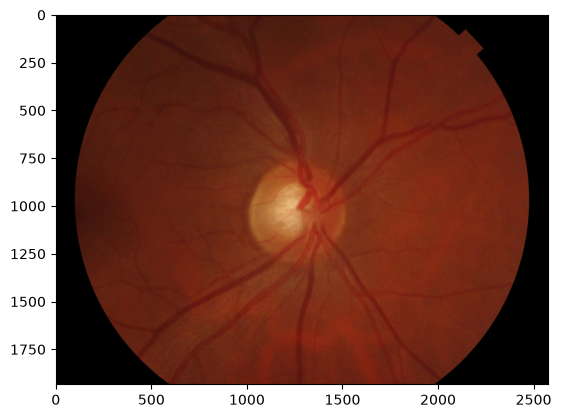

In [19]:
# you can have a look of some examples here
img = cv2.imread('../MEDFAIR_datasets/PAPILA/FundusImages/RET002OD.jpg')
print(img.shape)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

In [20]:
# Save images into pickle files
# This is optional, but if you are training many models, this step can save a lot of time by reducing the data IO.

In [21]:
pkl_dir = Path("../MEDFAIR_datasets/PAPILA/pkls")
pkl_dir.mkdir(parents=True, exist_ok=True)

In [22]:
test_meta = pd.read_csv('../MEDFAIR_datasets/PAPILA/split/new_train.csv')

print("1")

path = '../MEDFAIR_datasets/PAPILA/pkls/'
path_1 = '../MEDFAIR_datasets/PAPILA/FundusImages/'
images = []
start = time.time()
print(start)
for i in range(len(test_meta)):

    img = cv2.imread(path_1 + test_meta.iloc[i]['Path'])
    # resize to the input size in advance to save time during training
    img = cv2.resize(img, (256, 256))
    images.append(img)
    
end = time.time()
print(end)
end-start

with open(path + 'train_images.pkl', 'wb') as f:
    pickle.dump(images, f)

print("Finish")

1
1783764760.578601
1783764766.027641
Finish


In [23]:
test_meta = pd.read_csv('../MEDFAIR_datasets/PAPILA/split/new_val.csv')

print("2")

path = '../MEDFAIR_datasets/PAPILA/pkls/'
path_1 = '../MEDFAIR_datasets/PAPILA/FundusImages/'
images = []
start = time.time()
print(start)
for i in range(len(test_meta)):

    img = cv2.imread(path_1 + test_meta.iloc[i]['Path'])
    # resize to the input size in advance to save time during training
    img = cv2.resize(img, (256, 256))
    images.append(img)
    
end = time.time()
print(end)
end-start

with open(path + 'val_images.pkl', 'wb') as f:
    pickle.dump(images, f)

print("Finish")

2
1783764767.532201
1783764768.3253372
Finish


In [24]:
test_meta = pd.read_csv('../MEDFAIR_datasets/PAPILA/split/new_test.csv')

print("3")

path = '../MEDFAIR_datasets/PAPILA/pkls/'
path_1 = '../MEDFAIR_datasets/PAPILA/FundusImages/'
images = []
start = time.time()
print(start)
for i in range(len(test_meta)):

    img = cv2.imread(path_1 + test_meta.iloc[i]['Path'])
    # resize to the input size in advance to save time during training
    img = cv2.resize(img, (256, 256))
    images.append(img)
    
end = time.time()
print(end)
end-start

with open(path + 'test_images.pkl', 'wb') as f:
    pickle.dump(images, f)

print("Finish")

3
1783764771.445809
1783764773.0355031
Finish


In [25]:
!pwd

/Users/yiifann2021/Desktop/MEDFAIR_SAMMOO/notebooks


In [26]:
import json
import pickle
import pandas as pd
from pathlib import Path


with open("../configs/datasets.json", "r") as f:
    config = json.load(f)["PAPILA"]

pairs = [
    ("train", config["train_meta_path"], config["pickle_train_path"]),
    ("val", config["val_meta_path"], config["pickle_val_path"]),
    ("test", config["test_meta_path"], config["pickle_test_path"]),
]

print(pairs)

%cd ..

for split_name, csv_path, pkl_path in pairs:
    csv_path = Path(csv_path)
    pkl_path = Path(pkl_path)

    print(f"\n检查 {split_name} 数据集")
    print("CSV 是否存在：", csv_path.exists())
    print("PKL 是否存在：", pkl_path.exists())

    metadata = pd.read_csv(csv_path)

    with open(pkl_path, "rb") as f:
        images = pickle.load(f)

    print("CSV 样本数量：", len(metadata))
    print("PKL 图片数量：", len(images))
    print("数量是否一致：", len(metadata) == len(images))
    print("第一张图片形状：", images[0].shape)

    # 避免三个 pickle 同时占用内存
    del images

[('train', 'MEDFAIR_datasets/PAPILA/split/new_train.csv', 'MEDFAIR_datasets/PAPILA/pkls/train_images.pkl'), ('val', 'MEDFAIR_datasets/PAPILA/split/new_val.csv', 'MEDFAIR_datasets/PAPILA/pkls/val_images.pkl'), ('test', 'MEDFAIR_datasets/PAPILA/split/new_test.csv', 'MEDFAIR_datasets/PAPILA/pkls/test_images.pkl')]
/Users/yiifann2021/Desktop/MEDFAIR_SAMMOO

检查 train 数据集
CSV 是否存在： True
PKL 是否存在： True
CSV 样本数量： 294
PKL 图片数量： 294
数量是否一致： True
第一张图片形状： (256, 256, 3)

检查 val 数据集
CSV 是否存在： True
PKL 是否存在： True
CSV 样本数量： 42
PKL 图片数量： 42
数量是否一致： True
第一张图片形状： (256, 256, 3)

检查 test 数据集
CSV 是否存在： True
PKL 是否存在： True
CSV 样本数量： 84
PKL 图片数量： 84
数量是否一致： True
第一张图片形状： (256, 256, 3)
